# AI for Chemistry — Week 10, Session A
## Frontier applications and pitfalls

**Course:** AI for Chemistry · **Session:** 10A (interleaved lecture + lab,
2.5 h) · **Runtime:** < 60 s, no GPU.

### Suggested timing (solo study, ~120 min)

| Section | Topic | Time |
|--------:|-------|-----:|
| 0 | Setup | 8 min |
| 1 | A GNN for a real DFT property (QM9) | 28 min |
| 2 | Modern invariant/equivariant potentials (survey) | 12 min |
| 3 | How much does the train/test split matter? | 26 min |
| 4 | A pitfalls checklist for this course | 20 min |
| 5 | Exercises (4) | 26 min |

### Learning objectives
1. Train a GNN on a real DFT-computed property (QM9 HOMO-LUMO gap) and report
   its error honestly against a baseline. *(LO4, LO7)*
2. Name modern invariant/equivariant molecular-potential architectures and
   explain, at survey level, why equivariant internal layers tend to help. *(LO6, LO7)*
3. Quantify split-to-split variance with repeated random splits, and use it
   to judge whether a leaderboard difference is real. *(LO3, LO8)*
4. Apply a pitfalls checklist (leakage, benchmark choice, reproducibility)
   built from the whole course. *(LO8)*

### Prerequisites — before this notebook you should be able to
- Week 07: the `GCNLayer`/`GCN` classes and mini-batch training loop.
- Week 03A: cross-validation and why a single split is a noisy estimate.

### How to use this notebook (solo study)
Read, run, check each **✅** cell in order. This is the **solutions**
notebook.

### Dataset — QM9 (a 3000-molecule subsample)
QM9 is a standard benchmark: ~134,000 small molecules (up to 9 heavy atoms
from C, N, O, F) with **DFT-computed** properties (B3LYP/6-31G(2df,p)). We
use a fixed, checksum-derived 3000-molecule subsample
(`sources/datasets/qm9_subset.csv`) and predict the **HOMO-LUMO gap**, in eV
— electronically, a rough proxy for chemical reactivity/stability.


---
## 0. Setup

Rebuild each molecule as a 2D bond graph, exactly Week 07's `GCNLayer`/`GCN`
classes and element/atom-feature scheme — **not** dmol.pub's own 3D
inverse-distance edge features (a disclosed scope simplification;
`outline.md`).

**What to look for:** `3000` molecules, `3` to `9` heavy atoms each — QM9
molecules are much smaller than ESOL's.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors
RDLogger.DisableLog("rdApp.*")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

SEED = 0xC0FFEE
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path.cwd()
while not (ROOT / "sources").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "sources" / "datasets"
FIGDIR = ROOT / "lectures" / "week-10_applications-pitfalls" / "slides" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

qm9 = pd.read_csv(DATA / "qm9_subset.csv")
mols = [Chem.MolFromSmiles(s) for s in qm9["smiles"]]
y = qm9["gap_eV"].to_numpy().astype(np.float32)
sizes = [m.GetNumAtoms() for m in mols]
print(f"{len(mols)} molecules, {min(sizes)}-{max(sizes)} heavy atoms "
      f"(mean {np.mean(sizes):.1f})")
print(f"gap: {y.min():.2f} - {y.max():.2f} eV (mean {y.mean():.2f}, std {y.std():.2f})")


3000 molecules, 3-9 heavy atoms (mean 8.8)
gap: 2.24 - 10.87 eV (mean 6.83, std 1.28)


In [2]:
ELEMENTS = ["C", "N", "O", "F"]                 # QM9 heavy atoms only
N_ELEM = len(ELEMENTS) + 1
N_EXTRA = 4
N_FEAT = N_ELEM + N_EXTRA

def mol_to_graph(mol):
    """RDKit Mol -> (node features, adjacency-with-self-loops) -- Week 07's scheme."""
    n = mol.GetNumAtoms()
    X = np.zeros((n, N_FEAT), dtype=np.float32)
    for i, atom in enumerate(mol.GetAtoms()):
        elem_idx = ELEMENTS.index(atom.GetSymbol()) if atom.GetSymbol() in ELEMENTS else len(ELEMENTS)
        X[i, elem_idx] = 1.0
        X[i, N_ELEM + 0] = atom.GetDegree() / 4.0
        X[i, N_ELEM + 1] = float(atom.GetIsAromatic())
        X[i, N_ELEM + 2] = float(atom.IsInRing())
        X[i, N_ELEM + 3] = float(atom.GetFormalCharge())
    A = np.zeros((n, n), dtype=np.float32)
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        A[i, j] = A[j, i] = 1.0
    A += np.eye(n, dtype=np.float32)
    return torch.tensor(X), torch.tensor(A)

graphs = [mol_to_graph(m) for m in mols]

class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features, activation=None):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        self.activation = activation

    def forward(self, X, A):
        degree = A.sum(dim=-1, keepdim=True).clamp(min=1.0)
        out = self.W((A @ X) / degree)
        return self.activation(out) if self.activation is not None else out

class GCN(nn.Module):
    def __init__(self, n_layers=3, hidden=64, in_features=N_FEAT):
        super().__init__()
        dims = [in_features] + [hidden] * n_layers
        self.layers = nn.ModuleList(
            [GCNLayer(dims[i], dims[i + 1], activation=F.relu) for i in range(n_layers)])
        self.fc1 = nn.Linear(hidden, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, X, A):
        h = X
        for layer in self.layers:
            h = layer(h, A)
        g = h.mean(dim=0)
        g = F.relu(self.fc1(g))
        return self.fc2(g)


> **Common errors — Setup**
> - Reusing Week 07's `ELEMENTS` list (which included Cl, S, Br, P, I for
>   ESOL) — QM9 only contains C, N, O, F; an oversized element vocabulary is
>   harmless but wastes a few input dimensions on elements that never occur.


### ✅ Check yourself — Section 0

Prints `Section 0 OK`. 3000 molecules, no more than 9 heavy atoms each.


In [3]:
# --- checkpoint (do not edit) ---
assert len(mols) == 3000
assert max(sizes) <= 9
print("Section 0 OK")


Section 0 OK


**Conceptual questions**


1. QM9 molecules (up to 9 heavy atoms) are much smaller than ESOL's (up to
   55). What effect should that have on GCN training speed?
2. Why cache only a 3000-molecule subsample rather than the full ~134,000?


**Answers**


1. Smaller graphs mean smaller adjacency matrices and fewer nodes to
   aggregate per `GCNLayer` call, so both the forward and backward pass per
   molecule are cheaper — QM9 training here is faster per-molecule than
   Week 07's ESOL training despite a similar architecture.
2. Repository size and session runtime: the full file is ~30 MB (against
   this course's other cached datasets at ~100-150 KB), and 3000 molecules
   is already enough to demonstrate a real, checkable GNN result within the
   laptop-CPU time budget.


---
## 1. A GNN for a real DFT property

We train Week 07's exact GCN architecture, unchanged, on a genuinely
different task and dataset — a direct test of how much of that pipeline
**generalises**. Normalising the target (subtract the training mean, divide
by the training standard deviation) before training is standard practice for
regression targets on an unfamiliar numeric scale (here, several eV).

**What to look for:** the GNN's test MAE is meaningfully below the
mean-predictor baseline's — real, if modest, learning of a genuine
electronic-structure property from 2D connectivity alone.


In [4]:
idx = np.arange(len(mols))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
y_train_mean, y_train_std = y[idx_train].mean(), y[idx_train].std()
y_norm = (y - y_train_mean) / y_train_std        # normalise using TRAIN statistics only

def train_qm9_gcn(n_layers=3, hidden=64, epochs=40, batch_size=32, lr=5e-3, seed=0):
    torch.manual_seed(seed)
    model = GCN(n_layers=n_layers, hidden=hidden)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    rng = np.random.default_rng(seed)
    for epoch in range(epochs):
        model.train()
        order = idx_train.copy(); rng.shuffle(order)
        optimiser.zero_grad()
        for count, i in enumerate(order, 1):
            X, A = graphs[i]
            loss = loss_fn(model(X, A), torch.tensor([y_norm[i]])) / batch_size
            loss.backward()
            if count % batch_size == 0:
                optimiser.step(); optimiser.zero_grad()
        optimiser.step(); optimiser.zero_grad()
    return model

t0 = time.time()
qm9_gcn = train_qm9_gcn()
print(f"training time: {time.time() - t0:.1f} s")

qm9_gcn.eval()
with torch.no_grad():
    preds_norm = np.array([qm9_gcn(*graphs[i]).item() for i in idx_test])
preds_gcn = preds_norm * y_train_std + y_train_mean        # undo normalisation

gcn_mae = mean_absolute_error(y[idx_test], preds_gcn)
baseline_mae = mean_absolute_error(y[idx_test], np.full(len(idx_test), y_train_mean))
print(f"GCN test MAE:      {gcn_mae:.3f} eV")
print(f"baseline test MAE: {baseline_mae:.3f} eV")


training time: 24.3 s
GCN test MAE:      0.843 eV
baseline test MAE: 1.099 eV


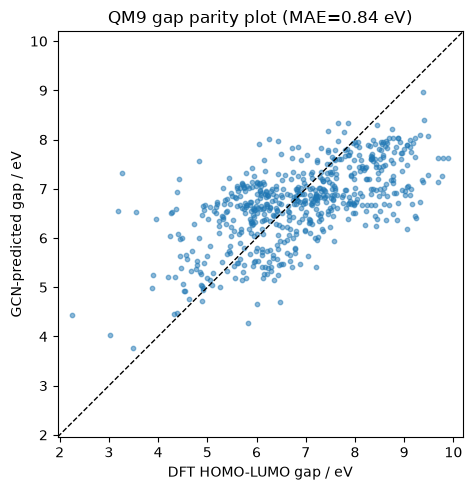

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
lims = [y[idx_test].min() - 0.3, y[idx_test].max() + 0.3]
ax.plot(lims, lims, "k--", lw=1)
ax.scatter(y[idx_test], preds_gcn, s=10, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("DFT HOMO-LUMO gap / eV"); ax.set_ylabel("GCN-predicted gap / eV")
ax.set_title(f"QM9 gap parity plot (MAE={gcn_mae:.2f} eV)")
fig.tight_layout(); fig.savefig(FIGDIR / "qm9_gap_parity_plot.png", dpi=200)
plt.show()


> **Common errors — Section 1**
> - Normalising the target using **test-set** statistics — a Week 02B-style
>   leak; `y_train_mean`/`y_train_std` must come from `idx_train` only, as
>   above.
> - Expecting this small, from-scratch, 2D-only model to approach published
>   QM9 benchmarks — state-of-the-art models use 3D geometry, much larger
>   training sets and far more tuning; dmol.pub's own equivalent example
>   reports an explicitly "undertrained" result too. `TODO(verify)`: specific
>   published MAE figures for HOMO-LUMO gap prediction, if quoting one.


### ✅ Check yourself — Section 1

Prints `Section 1 OK`. GCN test MAE is below the trivial baseline's.


In [6]:
# --- checkpoint (do not edit) ---
assert gcn_mae < baseline_mae
assert (FIGDIR / "qm9_gap_parity_plot.png").is_file()
print("Section 1 OK")


Section 1 OK


**Conceptual questions**


1. Why normalise the *target* here, when Week 07's ESOL target (log S) was
   used without normalisation?
2. The parity plot likely shows more scatter at the extremes (very small or
   very large gaps) than in the middle. Give one plausible reason.


**Answers**


1. Log S already sat in a moderate, roughly zero-centred range (~-13 to 2);
   HOMO-LUMO gaps here range several eV with a mean around 6-7 — normalising
   keeps the MSE loss's numeric scale in a range where the default Adam
   learning rate behaves well, a detail that matters more as the raw target
   scale drifts further from order-1.
2. Extreme values are rarer (fewer training examples with unusually small or
   large gaps), so the model has seen less to learn from there — the same
   "sparse region of the training distribution" issue that produces poor
   extrapolation everywhere in this course (Week 03's overfitting, Week 07's
   depth ablation).


---
## 2. Modern invariant/equivariant molecular potentials — survey

*(Survey-level, following dmol.pub's own chapter; no implementation.)*

Section 1's GCN uses only 2D connectivity. Real molecular **potentials**
(models predicting energies/forces from 3D geometry) split into two families,
directly extending Week 06's invariance/equivariance framework:

* **Invariant** architectures — **SchNet**, **ANI** — build their internal
  representations from rotation/translation-**invariant** quantities
  (interatomic distances) throughout every layer. Simpler to implement, but
  they must discard directional information at every step, which limits how
  precisely they can represent genuinely directional effects (e.g. bond
  angles, chirality-sensitive properties).
* **Equivariant** architectures — **NequIP**, **TorchMD-NET** — carry
  genuinely directional (vector/tensor) internal features that transform
  correctly under rotation, built from spherical harmonics and tensor
  products (Week 06A, Section 4). Reported to be **more accurate**,
  particularly in the low-training-data regime, at the cost of a more
  involved implementation. dmol.pub notes that, empirically, "the most
  important features in NequIP were data normalisation and how atom
  embeddings are treated" — implementation details matter as much as the
  headline architectural idea.

None of these are implemented in this course; Section 1's 2D `GCNLayer` is as
far as our own hands-on GNN implementation goes.


---
## 3. How much does the train/test split matter?

Every leaderboard in this course (Weeks 03, 06, 07, 08) has used **one**
fixed split. Pat Walters' `comparing_regression_models.ipynb` makes a
simple but easy-to-forget point: **repeat the split** and see how much the
score itself moves around, *before* trusting a small difference between two
models as meaningful.

We fit a fast classical baseline (random forest on RDKit descriptors) across
**10 different random splits** of the same QM9 subsample.

**What to look for:** MAE varies by several hundredths of an eV across
splits purely from *which* molecules happened to land in the test set — a
concrete number to compare any future "Model A beats Model B" claim against.


In [7]:
DESCRIPTORS = {
    "MolWt": Descriptors.MolWt, "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA, "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
}
Xdesc = np.array([[fn(m) for fn in DESCRIPTORS.values()] for m in mols], dtype=float)

split_maes = []
for seed in range(10):
    tr, te = train_test_split(idx, test_size=0.2, random_state=seed)
    rf = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1).fit(Xdesc[tr], y[tr])
    split_maes.append(mean_absolute_error(y[te], rf.predict(Xdesc[te])))

split_maes = np.array(split_maes)
print("MAE across 10 random splits:", np.round(split_maes, 3))
print(f"mean {split_maes.mean():.3f}  std {split_maes.std():.3f}  "
      f"range {split_maes.max() - split_maes.min():.3f} eV")


MAE across 10 random splits: [0.589 0.573 0.55  0.568 0.588 0.542 0.562 0.574 0.576 0.558]
mean 0.568  std 0.015  range 0.047 eV


/var/folders/h0/vgd3zhfj2s94q4030bkpt_2w0000gn/T/ipykernel_61923/1740837353.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(split_maes, vert=True)


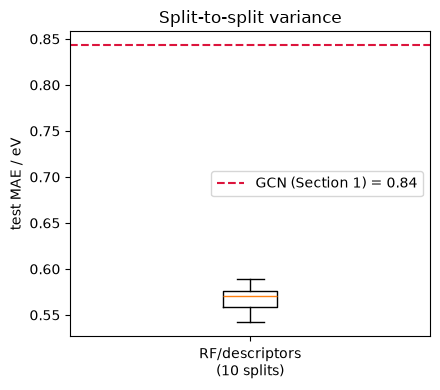

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.boxplot(split_maes, vert=True)
ax.axhline(gcn_mae, color="crimson", ls="--", label=f"GCN (Section 1) = {gcn_mae:.2f}")
ax.set_ylabel("test MAE / eV"); ax.set_xticks([1]); ax.set_xticklabels(["RF/descriptors\n(10 splits)"])
ax.set_title("Split-to-split variance"); ax.legend()
fig.tight_layout(); fig.savefig(FIGDIR / "split_variance_boxplot.png", dpi=200)
plt.show()


> **Common errors — Section 3**
> - Reporting only the mean across splits and discarding the spread — the
>   spread **is** the finding here; it tells you the smallest difference
>   worth taking seriously.
> - Concluding a random forest "beats" a GNN from one split each, when
>   Section 1's GCN MAE and this section's RF MAE differ by far more than
>   the split-to-split spread — that particular comparison, at least, *is*
>   large enough to be a real difference, not noise (worth checking
>   explicitly, as the checkpoint below does).


### ✅ Check yourself — Section 3

Prints `Section 3 OK`. Split-to-split MAE spread is small (std < 0.05 eV); the GCN-vs-RF/descriptors gap from Section 1 is much larger than that spread.


In [9]:
# --- checkpoint (do not edit) ---
assert len(split_maes) == 10
assert split_maes.std() < 0.05                              # splits agree to within ~0.05 eV
assert abs(gcn_mae - split_maes.mean()) > 3 * split_maes.std()  # GCN-vs-RF gap exceeds split noise
assert (FIGDIR / "split_variance_boxplot.png").is_file()
print("Section 3 OK")


Section 3 OK


**Conceptual questions**


1. If two models' MAEs differed by less than this section's split-to-split
   standard deviation, what would be the honest thing to say about which is
   "better"?
2. Why use `RandomForestRegressor` (fast, ~10 fits) for this study rather
   than repeating Section 1's GCN training 10 times?


**Answers**


1. That the difference is not distinguishable from split noise at this
   sample size — report both numbers and their uncertainty, and avoid
   declaring a winner on the strength of one comparison alone (exactly Week
   03A's cross-validation lesson, now quantified with an explicit number).
2. Practicality: the random forest trains in a fraction of a second per
   split, making 10 repeats cheap; repeating the GCN's mini-batch training
   10 times would multiply Section 1's already-longer training time by 10 —
   a legitimate trade-off to flag (Exercise 4 explores doing it anyway, at
   a reduced budget).


---
## 4. A pitfalls checklist, applied

A synthesis, not new material: every "Common errors" box across ten weeks
distilled into one checklist, applied here to Section 1's own QM9 study as a
worked example of **auditing your own work** — exactly what the mini-project
(Session B, and `assessments/mini-project-brief.md`) requires of you.

| Check | This notebook | Where the lesson came from |
|---|---|---|
| Deduplicated by canonical structure? | ✅ verified below | Week 02B |
| Train/test split fixed and disjoint? | ✅ `idx_train`/`idx_test` from one `train_test_split` call | Week 03 |
| Target normalised using **train** statistics only? | ✅ Section 1 | Week 02B/03 |
| A trivial baseline reported? | ✅ Section 1 | Week 03B/04 |
| Split-to-split variance quantified? | ✅ Section 3 | Week 03A, this section |
| Structure-aware (not just random) split considered? | ⚠️ **not done for QM9 above** | Week 02B/03B/04 |
| Reproducible (fixed seeds, stated environment)? | ✅ `SEED` fixed throughout | Week 01 onward |

**What to look for:** the deduplication check below confirms this specific
dataset needed no fixing — but the check itself is what matters, not the
(unsurprising, for an exhaustively-enumerated benchmark like QM9) result.


In [10]:
canonical = [Chem.MolToSmiles(m) for m in mols]
n_duplicates = len(canonical) - len(set(canonical))
print(f"duplicate structures in this QM9 subsample: {n_duplicates}")

# the one unchecked box: are train and test structurally similar (leakage risk)?
# -- left as Exercise 2 below, reusing Week 02B/03B's Butina-cluster machinery.


duplicate structures in this QM9 subsample: 0


> **Common errors — Section 4**
> - Treating a checklist pass as proof of a *correct* result — it only rules
>   out the *specific* failure modes on the list; a checklist is necessary,
>   not sufficient, diligence.
> - Skipping the structure-aware split check because "it probably doesn't
>   matter here" — Exercise 2 makes you actually check, rather than assume.


### ✅ Check yourself — Section 4

Prints `Section 4 OK`. No duplicate structures in this QM9 subsample.


In [11]:
# --- checkpoint (do not edit) ---
assert n_duplicates == 0
print("Section 4 OK")


Section 4 OK


**Conceptual questions**


1. Why would you expect QM9 specifically to have very few or no duplicate
   structures, unlike some datasets assembled from multiple literature
   sources?
2. Which single item on this checklist would you check **first** when
   auditing someone else's published ML-for-chemistry result, and why?


**Answers**


1. QM9 was generated by **exhaustive enumeration** of small molecules
   satisfying fixed constraints (up to 9 heavy atoms from a fixed element
   set), rather than aggregated from multiple overlapping literature
   sources (unlike, say, a merged bioactivity database) — there is no
   natural mechanism for the same structure to appear twice.
2. The split methodology (random vs structure-aware) — it is the item most
   likely to silently inflate a reported score, is checkable from the
   paper's methods section alone (no data or code needed), and directly
   determines whether the headline number should be trusted at all.


---
## 5. Exercises


### Exercise 1 — MAE in different units *(easy, ~10 min)*

Write `mae_in_kcalmol(mae_eV)` converting an MAE in eV to kcal/mol
(1 eV = 23.0609 kcal/mol — the unit dmol.pub's own historical QM9 discussion
uses). Report both units for Section 1's GCN and Section 3's RF/descriptors.

<details><summary>Show hint</summary>

One multiplication. `TODO(verify)` the exact conversion factor against a
primary source before using it in an assessed context.
</details>


In [12]:
EV_TO_KCALMOL = 23.0609   # TODO(verify) against a primary source

def mae_in_kcalmol(mae_eV):
    """Convert an MAE from eV to kcal/mol."""
    return mae_eV * EV_TO_KCALMOL

print(f"GCN:            {gcn_mae:.3f} eV = {mae_in_kcalmol(gcn_mae):.1f} kcal/mol")
print(f"RF/descriptors: {split_maes.mean():.3f} eV = {mae_in_kcalmol(split_maes.mean()):.1f} kcal/mol")


GCN:            0.843 eV = 19.4 kcal/mol
RF/descriptors: 0.568 eV = 13.1 kcal/mol


In [13]:
# --- check your answer (do not edit) ---
assert abs(mae_in_kcalmol(1.0) - 23.0609) < 1e-6
assert mae_in_kcalmol(gcn_mae) > mae_in_kcalmol(split_maes.mean())
print("Exercise 1 OK")


Exercise 1 OK


### Exercise 2 — the missing checklist item: a cluster split *(medium, ~18 min)*

Fill Section 4's one unchecked box. Using Morgan fingerprints and Butina
clustering (Week 02B/03B's `cluster_split` pattern), build a structure-aware
split of the QM9 subsample and re-score `RandomForestRegressor` on
descriptors. Does the score change much versus the random-split mean from
Section 3?

<details><summary>Show hint</summary>

`rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)`,
`Butina.ClusterData` with `isDistData=True` on a Tanimoto distance list,
then Week 02B's `cluster_split(clusters, n_total, test_frac=0.2, seed=0)`.
</details>


In [14]:
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.ML.Cluster import Butina

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = [mfpgen.GetFingerprint(m) for m in mols]

def tanimoto_distance_matrix(fp_list):
    dists = []
    for i in range(1, len(fp_list)):
        sims = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        dists.extend(1.0 - s for s in sims)
    return dists

def cluster_split(clusters, n_total, test_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    order = list(range(len(clusters))); rng.shuffle(order)
    test_mask = np.zeros(n_total, dtype=bool)
    target = int(np.ceil(test_frac * n_total))
    for c in order:
        if test_mask.sum() >= target:
            break
        for i in clusters[c]:
            test_mask[i] = True
    return ~test_mask, test_mask

dmat = tanimoto_distance_matrix(fps)
clusters = Butina.ClusterData(dmat, len(fps), 0.4, isDistData=True)
clusters = sorted(clusters, key=len, reverse=True)

train_mask, test_mask = cluster_split(clusters, len(mols), test_frac=0.2, seed=0)
rf_cluster = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1).fit(
    Xdesc[train_mask], y[train_mask])
cluster_split_mae = mean_absolute_error(y[test_mask], rf_cluster.predict(Xdesc[test_mask]))
print(f"cluster-split MAE: {cluster_split_mae:.3f} eV  "
      f"(random-split mean: {split_maes.mean():.3f} eV)")


cluster-split MAE: 0.576 eV  (random-split mean: 0.568 eV)


In [15]:
# --- check your answer (do not edit) ---
assert train_mask.sum() + test_mask.sum() == len(mols)
assert not (train_mask & test_mask).any()
assert cluster_split_mae > 0
print("Exercise 2 OK")


Exercise 2 OK


### Exercise 3 — is the GCN's error uniform across molecule size? *(medium, ~15 min)*

Write `mae_by_size(y_true, y_pred, sizes)` returning a `pandas.Series` of MAE
grouped by heavy-atom count. Apply it to Section 1's GCN test predictions.

<details><summary>Show hint</summary>

Build a small `DataFrame` with columns `error = abs(y_true - y_pred)` and
`size`, then `.groupby("size")["error"].mean()`.
</details>


In [16]:
def mae_by_size(y_true, y_pred, sizes):
    """MAE grouped by molecule size (heavy-atom count)."""
    df = pd.DataFrame({"error": np.abs(y_true - y_pred), "size": sizes})
    return df.groupby("size")["error"].mean()

test_sizes = [sizes[i] for i in idx_test]
mae_size = mae_by_size(y[idx_test], preds_gcn, test_sizes)
print(mae_size.round(3))


size
3    1.640
6    0.460
7    1.082
8    0.848
9    0.835
Name: error, dtype: float64


In [17]:
# --- check your answer (do not edit) ---
assert isinstance(mae_size, pd.Series)
assert mae_size.index.min() >= 3 and mae_size.index.max() <= 9
assert (mae_size > 0).all()
print("Exercise 3 OK")


Exercise 3 OK


### Exercise 4 — repeat the GCN itself, at a reduced budget *(harder, ~20 min)*

Section 3 used a fast classical model for the 10-split repeat because
repeating the GCN's full training would be slow. Write
`gcn_mae_across_seeds(n_seeds, epochs)` that retrains `train_qm9_gcn` for
several **model-initialisation** seeds (same split, different starting
weights) at a reduced `epochs` budget, and returns the list of test MAEs.
How does *this* spread compare to Section 3's split-to-split spread?

<details><summary>Show hint</summary>

Call `train_qm9_gcn(epochs=epochs, seed=s)` for `s` in `range(n_seeds)`,
keeping `idx_train`/`idx_test` fixed; score each on the same `idx_test`.
</details>


In [18]:
def gcn_mae_across_seeds(n_seeds, epochs=15):
    """Test MAE of train_qm9_gcn across several initialisation seeds (fixed split)."""
    maes = []
    for s in range(n_seeds):
        model = train_qm9_gcn(epochs=epochs, seed=s)
        model.eval()
        with torch.no_grad():
            preds = np.array([model(*graphs[i]).item() for i in idx_test])
        preds = preds * y_train_std + y_train_mean
        maes.append(mean_absolute_error(y[idx_test], preds))
    return maes

seed_maes = gcn_mae_across_seeds(n_seeds=3, epochs=15)
print("GCN MAE across 3 init seeds (15 epochs each):", np.round(seed_maes, 3))
print("spread:", round(max(seed_maes) - min(seed_maes), 3),
      " vs Section 3 split spread:", round(split_maes.max() - split_maes.min(), 3))


GCN MAE across 3 init seeds (15 epochs each): [0.864 0.869 0.889]
spread: 0.026  vs Section 3 split spread: 0.047


In [19]:
# --- check your answer (do not edit) ---
assert len(seed_maes) == 3
assert all(m > 0 for m in seed_maes)
print("Exercise 4 OK")


Exercise 4 OK


---
## Summary — what you learned

- Week 07's `GCNLayer`/`GCN`, reused **unchanged**, trained on a real DFT
  property (QM9 HOMO-LUMO gap) — a direct test of how much of a pipeline
  generalises to a new dataset and task.
- **Invariant vs equivariant** molecular potentials (SchNet/ANI vs
  NequIP/TorchMD-NET), survey-level, extending Week 06.
- **Split-to-split variance**, quantified with repeated random splits — the
  number to compare any future leaderboard claim against.
- A **pitfalls checklist** synthesising every "Common errors" box in the
  course, applied as a worked self-audit.

Session B applies this entire toolkit, end to end, to the mini-project
(assigned Week 06B) — the module's capstone.


## Further reading (course source list only)

- dmol.pub *Predicting DFT energies with GNNs*: <https://dmol.pub/applied/QM9.html>
- dmol.pub *Modern molecular neural networks*: <https://dmol.pub/dl/molnets.html>
- Pat Walters, `comparing_regression_models.ipynb`:
  <https://colab.research.google.com/github/PatWalters/practical_cheminformatics_tutorials/blob/main/ml_models/comparing_regression_models.ipynb>


## Attribution

Original teaching material for *AI for Chemistry*, adapted and rewritten from:

- **dmol.pub** (A. White) — the QM9 task framing (HOMO-LUMO gap, DFT
  properties) and the modern-architectures survey (SchNet, ANI, NequIP,
  TorchMD-NET); we reuse Week 07's own 2D `GCNLayer` rather than the
  chapter's 3D inverse-distance features (disclosed in `outline.md`).
  CC-BY 4.0. <https://dmol.pub>
- **Practical Cheminformatics** (P. Walters) — the repeated-split variance
  study motivated by `comparing_regression_models.ipynb`. MIT licence.
  <https://github.com/PatWalters/practical_cheminformatics_tutorials>

Dataset: QM9 (via the DeepChem mirror, checksum-pinned full download; a
fixed 3000-molecule subsample is cached). No verbatim text is reproduced
from the sources above.
